In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Lab 10 Exercise 1 - K-Means Geyser Eruption Segmentation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv"
df = pd.read_csv(url)
print(df.head())
print(df.shape)

   duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long
(272, 3)


In [ ]:
print(df.isnull().sum())
x = df[['duration', 'waiting']].values
print("Features shape:", x.shape)

duration    0
waiting     0
kind        0
dtype: int64
Features shape: (272, 2)


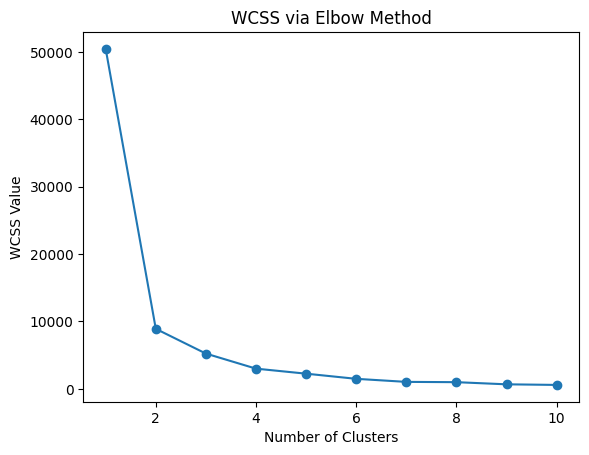

In [ ]:
wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    model.fit(x)
    wcss.append(model.inertia_)
plt.plot(range(1, 11), wcss, marker='o')
plt.title('WCSS via Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Value')
plt.show()

In [ ]:
model = KMeans(n_clusters=2, init='k-means++', random_state=42)
y_means = model.fit_predict(x)
print("Cluster labels:", y_means)
print("Cluster Centers:\n", model.cluster_centers_)

Cluster labels: [0 1 0 1 0 1 0 0 1 0 1 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1
 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0
 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 0 0
 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1
 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1
 0 0 0 1 0 1 1 0 0 1 0 1 0]
Cluster Centers:
 [[ 4.29793023 80.28488372]
 [ 2.09433    54.75      ]]


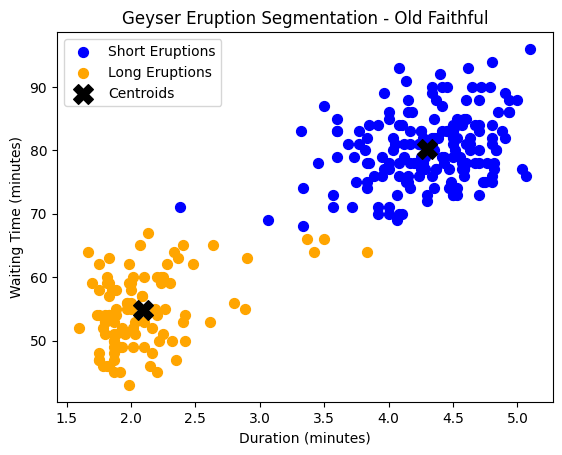

In [ ]:
plt.scatter(x[y_means==0, 0], x[y_means==0, 1], s=50, c='blue', label='Short Eruptions')
plt.scatter(x[y_means==1, 0], x[y_means==1, 1], s=50, c='orange', label='Long Eruptions')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroids')
plt.title('Geyser Eruption Segmentation - Old Faithful')
plt.xlabel('Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.legend()
plt.show()

In [ ]:
df['Cluster'] = y_means
print("\nCluster 0 - Short Eruptions:")
print(df[df['Cluster']==0].describe())
print("\nCluster 1 - Long Eruptions:")
print(df[df['Cluster']==1].describe())


Cluster 0 - Short Eruptions:
         duration     waiting  Cluster
count  172.000000  172.000000    172.0
mean     4.297930   80.284884      0.0
std      0.422677    5.627335      0.0
min      2.383000   68.000000      0.0
25%      4.062750   76.750000      0.0
50%      4.350000   80.000000      0.0
75%      4.587250   84.000000      0.0
max      5.100000   96.000000      0.0

Cluster 1 - Long Eruptions:
         duration     waiting  Cluster
count  100.000000  100.000000    100.0
mean     2.094330   54.750000      1.0
std      0.394762    5.895341      0.0
min      1.600000   43.000000      1.0
25%      1.833000   50.000000      1.0
50%      1.983000   54.000000      1.0
75%      2.221000   59.000000      1.0
max      3.833000   67.000000      1.0


In [ ]:
print("Observation:")
print("Cluster 1 - Short eruptions: shorter duration, shorter waiting time")
print("Cluster 2 - Long eruptions: longer duration, longer waiting time")
print("Elbow method confirms K=2 as optimal number of clusters")

Observation:
Cluster 1 - Short eruptions: shorter duration, shorter waiting time
Cluster 2 - Long eruptions: longer duration, longer waiting time
Elbow method confirms K=2 as optimal number of clusters
